# Conformal Abstention for Image Captioning

This notebook implements the conformal abstention technique from ["Mitigating LLM Hallucinations via Conformal Abstention"](https://arxiv.org/abs/2405.01563) for image captioning using GPT-4o generated captions.

# Setup

In [3]:
# add to path
import sys

sys.path.append("../")

# Libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Callable
import os
from datetime import datetime
from tqdm.notebook import tqdm
import warnings
import copy

from openai import OpenAI

OPENAI_CLIENT = OpenAI()
OPENAI_CLIENT.api_key = os.getenv("OPENAI_API_KEY")

In [4]:
# load scripts
from gpt4o_captioner import generate_caption
from constants import get_prompt

VLM_PROMPT = get_prompt()

ModuleNotFoundError: No module named 'scripts'

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Set style for plots
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# pandas settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# misc
warnings.filterwarnings("ignore")

# Data Loading
We use the dataset from the ASSETS paper that includes annotations for what we think is in the image. In this dataset, all images have a correct label from a human annotator.

In [6]:
target_images_dtypes = {
    "image_id": int,
    "file_name": str,
    "vizwiz_url": str,
    "image_preview": str,
    "INCLUDE because product": str,
    "EXCLUDE because not verifable": str,
    "EXCLUDE because Book/DVD/CD/magazine?": str,
    "text_detected": str,
    "IQ quality check": str,
    "unrecognizable": bool,
    "framing": bool,
    "blur": bool,
    "obstruction": bool,
    "rotation": bool,
    "too dark": bool,
    "too bright": bool,
    "other": bool,
    "no issue": bool,
    "unrecognizable_orig": int,
    "framing_orig": int,
    "blur_orig": int,
    "obstruction_orig": int,
    "rotation_orig": int,
    "too dark_orig": int,
    "too bright_orig": int,
    "human_caption_0": str,
    "human_caption_1": str,
    "human_caption_2": str,
    "human_caption_3": str,
    "human_caption_4": str,
    "gpt-4o-2024-08-06_caption": str,
    "Llama-3.2-11B-Vision-Instruct_caption": str,
    "Molmo-7B-O-0924_caption": str,
    "general_notes": str,
    "gpt-4o-2024-08-06_notes": str,
    "Llama-3.2-11B-Vision-Instruct_notes": str,
    "Molmo-7B-O-0924_notes": str,
    "unable_to_verify": str,
    "gpt4o_code": str,
    "llama_code": str,
    "molmo_code": str,
    "notes": str,
    "double code notes": str,
    "double verified": str,
    "curved label": str,
    "text panel": str,
    "AMP_rotation": str,
    "XT_rotation": str,
}

annotations_df = pd.read_csv(
    "../../study-analysis/study-2-product-analysis/annotated-data/final-annotated-images_1696-images_2025-04-15_15-00.csv",
    dtype=target_images_dtypes,
    keep_default_na=False,
)

print(f"Number of annotated images: {len(annotations_df)}")
print(
    f"Number of images that were verified: {len(annotations_df[annotations_df['unable_to_verify'] == ''])}"
)
annotations_df.head()

Number of annotated images: 1696
Number of images that were verified: 1220


,image_id,file_name,vizwiz_url,image_preview,human_captions,annotator,notes,unable_to_verify,double code notes,double verified,gpt4o_caption,gpt4o_code,llama_caption,llama_code,molmo_caption,molmo_code,text_detected,unrecognizable_orig,framing_orig,blur_orig,obstruction_orig,rotation_orig,too_dark_orig,too_bright_orig,other_orig,curved label,text panel,AMP_rotation,XT_rotation,expert_caption,unrecognizable,framing,blur,obstruction,rotation,too dark,too bright,other
0,16253,VizWiz_train_00016253.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,,A cup of hot chocolate with cookies next to it...,Anne Marie,,yes,,x,A white mug filled with a frothy drink topped ...,,The image shows a white mug with a handle on t...,,The image shows a white mug containing a light...,,True,0,4,0,2,0,2,1,0,,,,,,False,True,False,True,False,True,False,False
1,1210,VizWiz_train_00001210.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,,The cooking instructions on a package of a foo...,Anne Marie,,yes,,x,A printed instruction sheet with text and illu...,,The image shows a white and green plastic cont...,,The image shows a green plastic food storage c...,,True,0,4,0,0,0,0,0,0,,x,,,,False,True,False,False,False,False,False,False
2,8939,VizWiz_train_00008939.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,,A can of something with a lime green and dark ...,Anne Marie,,yes,,x,A green can with a black lid and design elemen...,,The image shows a cylindrical can with a green...,,"A green cylindrical can with a black lid, like...",,True,1,4,0,0,0,0,0,0,x,x,,,,False,True,False,False,False,False,False,False
3,8607,VizWiz_train_00008607.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,,Quality issues are too severe to recognize vis...,Anne Marie,,yes,,x,A can with a partially visible label featuring...,,The object is a silver can with a red label fe...,,A can of diced tomatoes is visible on a granit...,,True,1,4,0,0,0,0,0,0,x,,,,,False,True,False,False,False,False,False,False
4,16752,VizWiz_train_00016752.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,,A white bag of instant flour mix for preparing...,Anne Marie,,yes,,x,Nutrition facts and ingredient list from a foo...,,The image shows a nutrition label on a food pr...,,The image shows a nutrition label on a food pa...,,True,0,4,0,0,0,0,0,0,,x,,,,False,True,False,False,False,False,False,False


## Selecting relevant data for abstention testing
The current dataset includes annotations for 3 different models. Let's focus on just GPT-4o for now.

In [ ]:
relevant_data_df = annotations_df[annotations_df["unable_to_verify"] == ""][
    [
        "image_id",
        "file_name",
        "vizwiz_url",
        "human_captions",
        "annotator",
        "notes",
        "gpt4o_caption",
        "gpt4o_code",
    ]
]

# replace yes++ in gpt4o_code with yes
relevant_data_df["gpt4o_code"] = relevant_data_df["gpt4o_code"].str.replace(
    "yes++", "yes"
)

relevant_data_df.rename(columns={"notes": "annotation"}, inplace=True)
display(relevant_data_df.head())
print(f"Number of images: {len(relevant_data_df)}")
display(relevant_data_df["gpt4o_code"].value_counts())

# create a dictionary of the relevant data which is easier for processing
relevant_data = relevant_data_df.to_dict(orient="records")

,image_id,file_name,vizwiz_url,human_captions,annotator,annotation,gpt4o_caption,gpt4o_code
437,16588,VizWiz_train_00016588.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,"House keys, medicine, and a package with the t...",Anne Marie,pall mall cigarettes,A pack of Pall Mall cigarettes with a green de...,yes
438,15621,VizWiz_train_00015621.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,a person's hand is covering a bottle of bubble...,Anne Marie,bath and body works bubble bath moonlight path,"A hand is holding a bottle labeled ""moonlight ...",yes
439,7225,VizWiz_train_00007225.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,A package of cigarettes resting on black leath...,Anne Marie,marlboro cigarettes,A pack of Marlboro cigarettes with a red and w...,yes
440,3429,VizWiz_train_00003429.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,A 2 liter bottle of Pepsi and someone's hand.\...,Kapil,Bottle of regular pepsi,"A bottle of Pepsi with a red, white, and blue ...",yes
441,17399,VizWiz_train_00017399.jpg,https://vizwiz.cs.colorado.edu/VizWiz_visualiz...,A seasoned steak food product in white packagi...,Anne Marie,seasoned steak carmel color,"A packaging bag with visible text that reads ""...",yes


Number of images: 1220


gpt4o_code
yes    842
no     378
Name: count, dtype: int64

# Create Calibration Dataset
Let's define our dataset as $D = \{(X_1,Y_1),...,(X_n,Y_n)\}$. For image captioning:
- $\mathcal{X}$ is a space of input images
- $\mathcal{Y}$ is a space of output captions

To determine an abstention threshold, we need a subset of this data for the calibration set. We define this as $$D_n = \{(X_1,Y_1),...,(X_n,Y_n)\}  \subset \mathcal{X} \times \mathcal{Y}$$ 
which is a collection of ground truth query-response pairs. So, $(X_i, Y_i)$ are image-caption pairs where $Y_i$ is the ground truth caption for image $X_i$.

In [9]:
K_SAMPLES = 10
CALIBRATION_SIZE = 100
TEST_SIZE = 300
RANDOM_STATE = 42

In [10]:
def create_calibration_dataset(
    relevant_data,
    calibration_size=100,
    random_state=42,
    balance_correctness=True,
    desired_correctness=0.5,
):
    """
    Create calibration dataset to compute abstention threshold.

    Args:
        relevant_data: List of dictionaries containing image_id, annotation, gpt4o_caption, gpt4o_code
        calibration_size: Size n of calibration set
        random_state: For reproducibility
        balance_correctness: Whether to balance the correctness of the calibration set
        desired_correctness: Desired correctness of the calibration set

    Returns:
        dict: Contains calibration_data and remaining_data
    """
    np.random.seed(random_state)

    # Validate input data
    if not relevant_data:
        raise ValueError("No relevant data provided")

    if len(relevant_data) < calibration_size:
        print(f"Warning: Only {len(relevant_data)} samples available, using all")
        calibration_size = len(relevant_data)

    if balance_correctness:
        # balance the correctness of the calibration set
        correct_indices = [
            i
            for i in range(len(relevant_data))
            if relevant_data[i]["gpt4o_code"] == "yes"
        ]
        incorrect_indices = [
            i
            for i in range(len(relevant_data))
            if relevant_data[i]["gpt4o_code"] == "no"
        ]

        # get the desired number of correct and incorrect samples
        desired_correct_samples = int(calibration_size * desired_correctness)
        desired_incorrect_samples = calibration_size - desired_correct_samples

        # get the correct and incorrect samples
        correct_indices = np.random.choice(
            correct_indices, size=desired_correct_samples, replace=False
        )
        incorrect_indices = np.random.choice(
            incorrect_indices, size=desired_incorrect_samples, replace=False
        )

        # combine the correct and incorrect samples
        calibration_indices = np.concatenate([correct_indices, incorrect_indices])
        np.random.shuffle(calibration_indices)

    else:
        calibration_indices = np.random.choice(
            range(len(relevant_data)), size=calibration_size, replace=False
        )

    calibration_data = [relevant_data[i] for i in calibration_indices]

    # also returning remaining which will be used to create a test set
    remaining_indices = [
        i for i in range(len(relevant_data)) if i not in calibration_indices
    ]
    remaining_data = [relevant_data[i] for i in remaining_indices]

    return {
        "calibration_data": calibration_data,
        "remaining_data": remaining_data,
    }


def create_test_set(
    remaining_data,
    test_size=100,
    random_state=42,
    balance_correctness=True,
    desired_correctness=0.5,
):
    """
    Create test set from remaining data.

    Args:
        remaining_data: List of dictionaries containing image_id, annotation, gpt4o_caption, gpt4o_code
        test_size: Size n of test set
        random_state: For reproducibility
        balance_correctness: Whether to balance the correctness of the test set
        desired_correctness: Desired correctness of the test set

    Returns:
        dict: Contains test_data and remaining_data
    """
    np.random.seed(random_state)

    if not remaining_data:
        raise ValueError("No remaining data provided")

    if len(remaining_data) < test_size:
        print(f"Warning: Only {len(remaining_data)} samples available, using all")
        test_size = len(remaining_data)

    # TODO: duplicate code from above
    if balance_correctness:
        # balance the correctness of the test set
        correct_indices = [
            i
            for i in range(len(remaining_data))
            if remaining_data[i]["gpt4o_code"] == "yes"
        ]
        incorrect_indices = [
            i
            for i in range(len(remaining_data))
            if remaining_data[i]["gpt4o_code"] == "no"
        ]

        # get the desired number of correct and incorrect samples
        desired_correct_samples = int(test_size * desired_correctness)
        desired_incorrect_samples = test_size - desired_correct_samples

        # get the correct and incorrect samples
        correct_indices = np.random.choice(
            correct_indices, size=desired_correct_samples, replace=False
        )
        incorrect_indices = np.random.choice(
            incorrect_indices, size=desired_incorrect_samples, replace=False
        )

        # combine the correct and incorrect samples
        test_indices = np.concatenate([correct_indices, incorrect_indices])
        np.random.shuffle(test_indices)

    else:
        test_indices = np.random.choice(
            range(len(remaining_data)), size=test_size, replace=False
        )

    test_data = [remaining_data[i] for i in test_indices]

    # remaining data is whatever is left over
    remaining_data = [
        remaining_data[i] for i in range(len(remaining_data)) if i not in test_indices
    ]

    return {
        "test_data": test_data,
        "remaining_data": remaining_data,
    }

In [11]:
# overall stats
print(f"Total data size: {len(relevant_data)}")
correct_count = len([r for r in relevant_data if r["gpt4o_code"] == "yes"])
correct_percentage = correct_count / len(relevant_data)
print(f"Percentage of correct in total data: {100 * correct_percentage:.2f}%\n")

# Create the calibration dataset
# Paper typically uses 100-200 for calibration
calibration_result = create_calibration_dataset(
    relevant_data,
    calibration_size=CALIBRATION_SIZE,
    random_state=RANDOM_STATE,
    balance_correctness=True,
    desired_correctness=correct_percentage,
)

calibration_data = calibration_result["calibration_data"]
remaining_data = calibration_result["remaining_data"]

print(f"Calibration set size: {len(calibration_data)}")
print(
    f"Percentage of correct in calibration set: {100 * len([t for t in calibration_data if t['gpt4o_code'] == 'yes']) / len(calibration_data):.2f}%\n"
)

# create test set
test_result = create_test_set(
    remaining_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    balance_correctness=True,
    desired_correctness=correct_percentage,
)
test_data = test_result["test_data"]
remaining_data = test_result["remaining_data"]

print(f"Test set size: {len(test_data)}")
print(
    f"Percentage of correct in test set: {100 * len([t for t in test_data if t['gpt4o_code'] == 'yes']) / len(test_data):.2f}%\n"
)

print(f"Remaining set size: {len(remaining_data)}")
print(
    f"Percentage of correct in remaining set: {100 * len([r for r in remaining_data if r['gpt4o_code'] == 'yes']) / len(remaining_data):.2f}%"
)

Total data size: 1220
Percentage of correct in total data: 69.02%

Calibration set size: 100
Percentage of correct in calibration set: 69.00%

Test set size: 300
Percentage of correct in test set: 69.00%

Remaining set size: 820
Percentage of correct in remaining set: 69.02%


## Generating additional samples from the VLM
The following analysis will require additional samples from the VLM. Let $k$ be an integer. For each image-caption pair $(X_i, Y_i)$, we add $k$ samples $Y_i^1, ... Y_i^k$ from the VLM, given the query image $X$.

In [12]:
def get_additional_samples(image_dict, temperature=1.0, k=10):
    """
    Get additional samples from the VLM.

    Args:
        image_dict (dict): Dictionary containing image information.
        temperature (float): Temperature for the VLM. Default is 1.0.
        k (int): Number of additional samples to generate. Default is 10.

    Returns:
        list: List of additional samples.
    """
    # use gpt4o to get additional samples
    additional_samples = []
    for _ in range(k):
        try:
            output = generate_caption(
                image_dict["vizwiz_url"],
                OPENAI_CLIENT,
                VLM_PROMPT,
                temperature=temperature,
            )
            additional_samples.append(output)
        except Exception as e:
            print(f"Error generating caption: {e}")
    return additional_samples


def get_greedy_response(image_dict, temperature=0.0):
    """
    Get the greedy response from the VLM.

    Args:
        image_dict (dict): Dictionary containing image information.
        temperature (float): Temperature for the VLM. Default is 0.0.
    """
    return generate_caption(
        image_dict["vizwiz_url"],
        OPENAI_CLIENT,
        VLM_PROMPT,
        temperature=temperature,
    )


# directory where data will be saved and read from
os.makedirs("./input-data", exist_ok=True)

### Load or generate calibration data

In [13]:
# check if we have saved calibration data
if os.path.exists("./input-data/calibration_data.json"):
    with open("./input-data/calibration_data.json", "r") as f:
        calibration_data = json.load(f)
    print(f"Loaded {len(calibration_data)} calibration data")
else:
    print(
        "Generating greedy responses and additional samples for calibration data...",
        end="",
    )

    # generate a greedy caption and get additional samples for every image in the calibration set
    for index, image_data in tqdm(
        enumerate(calibration_data), total=len(calibration_data)
    ):
        calibration_data[index]["greedy_response"] = get_greedy_response(image_data)

        additional_samples = get_additional_samples(
            image_data, temperature=1.0, k=K_SAMPLES
        )

        if len(additional_samples) == K_SAMPLES:
            calibration_data[index]["additional_responses"] = additional_samples
        else:
            # TODO: temp fix: pad additional responses with the last sample
            print(
                f"Error generating {K_SAMPLES} additional samples for image {image_data['image_id']}"
            )
            additional_samples = additional_samples + [additional_samples[-1]] * (
                K_SAMPLES - len(additional_samples)
            )
            calibration_data[index]["additional_responses"] = additional_samples

    # save calibration data
    with open("./input-data/calibration_data.json", "w") as f:
        json.dump(calibration_data, f)
    print(
        f"Saved {len(calibration_data)} calibration data with greedy responses and {K_SAMPLES} additional samples"
    )

Loaded 100 calibration data


### Load or generate test data

In [14]:
# check if we have saved test data
if os.path.exists("./input-data/test_data.json"):
    with open("./input-data/test_data.json", "r") as f:
        test_data = json.load(f)
    print(f"Loaded {len(test_data)} test data")
else:
    print(
        "Generating greedy responses and additional samples for test data...",
        end="",
    )

    # generate a greedy caption and get additional samples for every image in the test set
    for index, image_data in tqdm(enumerate(test_data), total=len(test_data)):
        test_data[index]["greedy_response"] = get_greedy_response(image_data)
        test_data[index]["additional_responses"] = get_additional_samples(
            image_data, temperature=1.0, k=K_SAMPLES
        )

    # save test data
    with open("./input-data/test_data.json", "w") as f:
        json.dump(test_data, f)
    print(
        f"Saved {len(test_data)} test data with greedy responses and {K_SAMPLES} additional samples"
    )

Loaded 300 test data


# Problem Definition
Let $\mathcal{X}$ be the space of input images and $\mathcal{Y}$ the space of output captions generated by a VLM. We want to develop a *selective classifier*, $f: \mathcal{X} \rightarrow \mathcal{Y}$, that abstains from prediction (in this case, returning a caption for an image) when $f$ would make a mistake. We can define our abstention function as:
$$a_{\lambda}(X) = \begin{cases} 
1 & \text{if } g(X) < \lambda \textrm{ (abstain)}\\
0 & \text{if } g(X) \geq \lambda \textrm{ (don't abstain)}
\end{cases}$$

where:
- $g(X)$ is the **scoring function** that indicates the model's confidence in captioning $X$ ($g: \mathcal{X} \rightarrow \mathbb{R}$)
- $\lambda$ is the abstention threshold

To construct this classifer, we need the following:
1. The scoring function $g: \mathcal{X} \rightarrow \mathbb{R}$. This tells us how confident the VLM is in its generated response, based on multiple generated responses. We bound this value from 0-$k$ where $k$ is the number of additional VLM samples created; closer to $k$ indicates the model is more confident in its score.

2. A matching function $m: \mathcal{X} \times \mathcal{Y} \times \mathcal{Y} \rightarrow \{0,1\}$ that indicates if a sampled caption $Y'$ is semantically equivalent to $Y$ given $X$. This tells us if the model's output is correct, given a ground truth caption, which is our human annotation.
    - **$m(X; Y', Y) = 1$**: Generated caption is semantically equivalent to the annotation, for a given image.
    - **$m(X; Y', Y) = 0$**: Caption does not match annotation.

We can use these to define a *loss function* for the selective classifier:

$$\mathcal{L}(X, Y; \lambda) = (1 - a_\lambda(X))(1 - m(X; f(X), Y))$$

The idea here is that $\mathcal{L}$ penalizes a policy when it does not abstain and its response does not match the label (i.e., first quantity is a 1 since the classifier did not abstain, but the second quantity is also a 1 since the output did not match the ground truth). Note, however, that we could design a trivial policy where the classifier always abstains, resulting in 0 loss. 

Instead, let's define two quantities: 
1. Risk, $R(\lambda) = \mathbb{E}[\mathcal{L}(X, Y; \lambda)]$, of producing an incorrect answer on a new query

2. Rate of abstention, $T(\lambda) = \mathbb{E}[a_\lambda(X)]$, or how often the classifier chooses to abstain
where the expectations are taken over query-response pairs.

With these quantities, we want to find the abstention threshold $\lambda$ resulting in the smallest number of abstentions for a given risk tolerance $a > 0$: 

$$\textrm{argmin}_{\lambda} T(\lambda) \textrm{ subject to }  R(\lambda) \leq \mathcal{a} $$

Since $T(\lambda)$ is non-decreasing, we ultimately want to find the smallest $\lambda$ for which $R(\lambda) \leq a$. 


## How do we implement this?
In summary, we need to do the following computationally. Starting with the calibration dataset:
1. Generate up to $k - 1$ samples from the VLM using the same `temperature` setting used in practice for a prompt (`temperature = 1.0` in our case), and a single response setting `temperature = 0.0` (for greedy decoding). We can use these responses as input to the scoring function to compute the model's confidence.
    - *Note: in this notebook, this is done before the current Problem Definition block.*

2. Then, we use the matching function to compute whether the generated caption was correct, versus the human annotation.
    - **NOTE** that as a proxy, we can probably use the human-labeled correctness code during the calibration?

3. (1) and (2) allow us to compute the loss over the entire calibration dataset, at different levels of $\lambda$. For each $\lambda$, we can also compute the risk and rate of abstention. 
    - **NOTE**: $\lambda$ here, I think, is in the range $[0, k]$ since the scoring function $g(X)$ will return the $k$ number of responses matching the query (or expected value of $k$).

4. Once you have a $\lambda$, then you only need to compute $a(X)$ for a new query, $X$. 

## Define scoring functions
The paper defines 2 scoring functions:
1. Match count: looks at the number of other responses similar to the current response. Formally: a match is found if $| j \neq i: s(X; Y^i, Y^j) > \beta$|, where $\beta$ is a positive scalar parameter defined by the implementer. 
    - In the paper, $\beta = 7$ based on the author's observations of error rate in the matching function on their dataset.
    - The default response $f(X)$ is the response with the largest score, and $g(X)$ is the score of $f(X)$. 
    - This policy abstains if the score is less than $\lambda$, returning $f(X)$ otherwise.
    - Matches are computed by asking an LLM to judge similarity between responses.

2. Expected match count: rather than comparing pairwise with multiple LLM comparisons, an alternative is to ask the LLM what the expected number of matches is. Then, the score becomes the expected match count: $g(X) = \Sigma_{i=1}^k q(\textrm{``i''} | X)i$, where $q$ is the probability of token $\textrm{``i''}$ according to the LLM.
    - **Note**: the way I interpret this is that you're computing the expected value over the possible number of matches (0 - k). So the likelyhood that it should be 1, 2, 3, ...k * the value. 
    - This requires access to the log-probablities of the model

In both cases, you can apply an optimization where you use the *greedy* output of the VLM as the comparison point, which is generated by setting `temperature = 0.0`. This reduces the comparions from $k^2$ to $k$. This is done below.  

**Important: in the following implementation, scores for $g(X)$ are cached for each scoring function.** This is done because hundreds of requests will be made for each $\lambda$ we want to check if not cached, but it shouldn't be needed since $g(X)$ does not depend on $\lambda$. **We should verify this is correct.**

In [27]:
def greedy_match_count_score(
    image_data: dict,
    beta_threshold: float = 8.0,
    should_cache: bool = True,
    fetch_from_cache: bool = True,
) -> float:
    """
    Count how many additional responses are similar to greedy response by doing pairwise comparisons using an LLM to score similarity.

    Assumes:
        - image_data["greedy_response"]: str, the greedy (zero-temp) caption
        - image_data["additional_responses"]: list of str, k additional captions

    Args:
        image_data: dict, image data containing greedy response and additional responses
        beta_threshold: float, threshold for similarity score to consider a match.
        - If the similarity score is greater than or equal to the threshold, we consider the captions to be a match.
        - If the similarity score is less than the threshold, we consider the captions to be different.
        -- TODO: this needs to be calibrated manually. The paper used 7, but looking at the results, I think we need a stricter threshold. So, I'm trying 8.
        should_cache: bool, whether to cache the similarity scores in the image_data dict.
        fetch_from_cache: bool, whether to fetch the similarity scores from the image_data dict.

    Returns:
        - Integer count from 0 to k that says how mnay pairs of responses were similar to the greedy response.
    """
    greedy_response = image_data.get("greedy_response", "")
    additional_responses = image_data.get("additional_responses", [])

    if not greedy_response or not additional_responses:
        return 0.0

    # set k to be the number of additional responses
    k = len(additional_responses)

    # check if we have cached the similarity scores
    if fetch_from_cache and "match_count_scores" in image_data:
        return image_data["match_count_scores"]["total_matches"]

    # define a similarity function
    def match_count_similarity(caption1: str, caption2: str, client) -> float:
        """LLM-based similarity scoring on 1-10 scale as used in paper."""
        try:
            # is this part needed? would an LLM need to know what the original prompt was (without the image) to compare the text?
            # prompt = (
            #     f"You are given a prompt to caption an image (Q), and two candidate captions (C and D). Given Q, measure the similarity of C and D on a scale of 0-10. Answer in a number between 0 and 10."
            #     f"\nQ: {VLM_PROMPT}"
            #     f"\nC: {caption1}"
            #     f"\nD: {caption2}"
            #     f"\nGiven Q, similarity of C and D to each other is [0-10]:"
            # )

            prompt = (
                f"You are given two captions (C and D). Measure the semantic similarity of C and D on a scale of 0-{k}. Answer in a number between 0 and {k}."
                f"\nC: {caption1}"
                f"\nD: {caption2}"
                f"\nGiven C and D, similarity of C and D to each other is [0-{k}]:"
            )

            response = client.chat.completions.create(
                model="gpt-4o-2024-08-06",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=5,
            )

            score = float(response.choices[0].message.content.strip())
            return max(1.0, min(10.0, score))

        except Exception as e:
            print(f"LLM similarity error: {e}")
            return 5.0

    # similar_count = 0
    # for response in additional_responses:
    #     similarity = match_count_similarity(greedy_response, response, OPENAI_CLIENT)
    #     if similarity >= beta_threshold:
    #         similar_count += 1

    # return float(similar_count)

    # compute the similarity scores
    similarity_scores = []
    similar_count = 0
    for response in additional_responses:
        similarity = match_count_similarity(greedy_response, response, OPENAI_CLIENT)
        if similarity >= beta_threshold:
            similar_count += 1
        similarity_scores.append(similarity)

    # cache the similarity scores
    if should_cache:
        image_data["match_count_scores"] = {
            "total_matches": float(similar_count),
            "similarity_scores": similarity_scores,
        }

    return float(similar_count)


# TODO: need to verify how this is working
def greedy_expected_match_count_score(
    image_data: dict, should_cache: bool = True, fetch_from_cache: bool = True
) -> float:
    """
    GREEDY EXPECTED MATCH COUNT: Ask LLM for expected count using probabilities.

    Assumes:
        - image_data["greedy_response"]: str, the greedy (zero-temp) caption
        - image_data["additional_responses"]: list of str, k additional captions

    Args:
        image_data: dict, image data containing greedy response and additional responses
        should_cache: bool, whether to cache the expected match count in the image_data dict.
        fetch_from_cache: bool, whether to fetch the expected match count from the image_data dict.

    Returns:
        - Expected value (can be non-integer) from 0 to k based on the LLM's probability distribution over the number of matches.
    """
    greedy_response = image_data.get("greedy_response", "")
    additional_responses = image_data.get("additional_responses", [])

    if not greedy_response or not additional_responses:
        return 0.0

    # set k to be the number of additional responses
    k = len(additional_responses)

    # see if we can fetch from cache
    if fetch_from_cache and "expected_match_count_scores" in image_data:
        return image_data["expected_match_count_scores"]["expected_value"]

    # compute the expected match count
    try:
        # Format all responses for LLM evaluation
        alternative_captions = ""
        for i, response in enumerate(additional_responses):
            alternative_captions += f"A{i + 1}. {response}\n"

        # prompt = (
        #     f"You are given a prompt to caption an image (Q), and a list of alternative captions (A1 -> A{k}). How many of the alternative captions are semantically the same as C, if any? Generic answers do not count. Answer in a number between 0 and {k}."
        #     f"\nQ: {VLM_PROMPT}"
        #     f"\nC: {greedy_response}"
        #     f"\n{alternative_captions}"
        #     f"\nThe number of supportive answers for C is [0-{k}]:"
        # )

        prompt = (
            f"You are given a caption (C) and a list of alternative captions (A1 -> A{k}). How many of the alternative captions are semantically the same as C, if any? Generic answers do not count. Answer in a number between 0 and {k}."
            f"\nC: {greedy_response}"
            f"\n{alternative_captions}"
            f"\nThe number of supportive answers for C is [0-{k}]:"
        )

        response = OPENAI_CLIENT.chat.completions.create(
            model="gpt-4o-2024-08-06",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            max_tokens=10,
            logprobs=True,
            top_logprobs=20,
        )

        # Extract expected value from token probabilities
        if response.choices[0].logprobs and response.choices[0].logprobs.content:
            token_probs = response.choices[0].logprobs.content[0].top_logprobs
            expected_value = 0.0

            # compute the expected value
            relevant_tokens = []
            for token_info in token_probs:
                token = token_info.token.strip()
                prob = np.exp(token_info.logprob)

                # only consider tokens that are numbers
                try:
                    count = float(token)
                    if 0 <= count <= k:  # Valid count
                        expected_value += prob * count
                    relevant_tokens.append({"token": token, "prob": prob})
                except ValueError:
                    continue

            # cache the expected match count
            if should_cache:
                image_data["expected_match_count_scores"] = {
                    "expected_value": expected_value,
                    "token_probs": relevant_tokens,
                }

            return expected_value
        else:
            # Fallback: parse direct response
            count = float(response.choices[0].message.content.strip())
            output = max(0.0, min(float(k), count))

            if should_cache:
                image_data["expected_match_count_scores"] = {
                    "expected_value": output,
                    "token_probs": [],
                }

            return output

    except Exception as e:
        print(f"Expected match count error: {e}")
        return 0.0


# Test both scoring functions
test_sample = calibration_data[1]
print(f"Testing with image_id: {test_sample['image_id']}")
print(f"Ground truth: '{test_sample['annotation']}'")
print(f"Greedy caption: {test_sample.get('greedy_response', '')[:60]}...")
print(f"Was correct?: {test_sample.get('gpt4o_code', '')}")

print("\n1. GREEDY MATCH COUNT SCORE:")
score_mc = greedy_match_count_score(test_sample)
print(f"   g_mc(X) = {score_mc} (integer count)")

print("\n2. GREEDY EXPECTED MATCH COUNT SCORE:")
score_emc = greedy_expected_match_count_score(test_sample)
print(f"   g_emc(X) = {score_emc:.2f} (expected value)")

Testing with image_id: 7393
Ground truth: 'ultra gain original detergent'
Greedy caption: A box of Gain detergent with "Ultra" and "Original" written ...
Was correct?: yes

1. GREEDY MATCH COUNT SCORE:
   g_mc(X) = 10.0 (integer count)

2. GREEDY EXPECTED MATCH COUNT SCORE:
   g_emc(X) = 3.80 (expected value)


In [28]:
test_sample

{'image_id': 7393,
 'file_name': 'VizWiz_train_00007393.jpg',
 'vizwiz_url': 'https://vizwiz.cs.colorado.edu/VizWiz_visualization_img/VizWiz_train_00007393.jpg',
 'human_captions': 'a yellow and green colored paper labelled with ultra ain original\nA box of Gain detergent is the original\nthe photo is of a  laundry detergent box.\nA green and yellow detergent box that weighs 11.4 pounds.\nyellow and green package for Ultra Gain, original.',
 'annotator': 'Anne Marie',
 'annotation': 'ultra gain original detergent',
 'gpt4o_caption': 'A box of Gain laundry detergent with "Ultra" written in red letters and "Original" in white letters against a green background. The box displays "183 OZ (11.4 LB) 5.2 kg" and notes "160 loads" with a graphic of grass and flowers at the bottom.',
 'gpt4o_code': 'yes',
 'greedy_response': 'A box of Gain detergent with "Ultra" and "Original" written on it. The packaging is green with images of grass and leaves, and it states "160 loads" and "183 oz (11.4 lb) 

## Define a matching function
Here, we define a function to check if two responses match if they are similar enough. The paper defines 2 approaches:
1. A term-based F1 score, which works well for short answers (e.g., Q&A) but not for open-ended resposnes, like image captions.
2. A semantic similarity score where you ask a LLM to judge the similarity between two responses. Here, you ask the model to return a score of 0-10 (10 being most similar), and a match is considered if the score is above a pre-specified threshold. 

However, since we have verified human annotations in our calibration dataset, we'll use that as our match function. The output will be binary: 1 if correct, 0 if incorrect.

In [15]:
def match_function(image_data: dict) -> int:
    """
    Match function that checks if the model's response matches the human annotation.

    Args:
        image_data: dict, image data containing greedy response and additional responses

    Returns:
        - 1 if the model's response matches the human annotation
        - 0 if the model's response does not match the human annotation
    """
    return 1 if image_data.get("gpt4o_code") == "yes" else 0


# Test the match function
test_sample = calibration_data[1]
print(f"Testing with image_id: {test_sample['image_id']}")
print(f"Ground truth: '{test_sample['annotation']}'")
print(f"Model's response: {test_sample.get('gpt4o_caption', '')}")
print(f"Was correct?: {test_sample.get('gpt4o_code', '')}")
print(f"Match function result: {match_function(test_sample)}")

Testing with image_id: 7393
Ground truth: 'ultra gain original detergent'
Model's response: A box of Gain laundry detergent with "Ultra" written in red letters and "Original" in white letters against a green background. The box displays "183 OZ (11.4 LB) 5.2 kg" and notes "160 loads" with a graphic of grass and flowers at the bottom.
Was correct?: yes
Match function result: 1


## Define a loss function for the selective classifier
Now we can define the loss function: 
$$\mathcal{L}(X, Y; \lambda) = (1 - a_\lambda(X))(1 - m(X; f(X), Y))$$

In [16]:
def loss_function(
    image_data: dict, score_fn: Callable, abstention_threshold: float
) -> float:
    """
    Loss function for the selective classifier.

    Args:
        image_data: dict, image data containing greedy response and additional responses
        score_fn: Callable, score function to use
        abstention_threshold: float, abstention threshold

    Returns:
        float, loss value
    """
    abstention_fn_loss = 1 - a_lambda(image_data, score_fn, abstention_threshold)
    match_fn_loss = 1 - match_function(image_data)

    # print(f"Abstention fn loss: {abstention_fn_loss}")
    # print(f"Match fn loss: {match_fn_loss}")

    return abstention_fn_loss * match_fn_loss


def a_lambda(
    image_data: dict, score_fn: Callable, abstention_threshold: float
) -> float:
    """
    Abstention function for the selective classifier.

    Args:
        image_data: dict, image data containing greedy response and additional responses
        score_fn: Callable, score function to use
        abstention_threshold: float, abstention threshold

    Returns:
        float, abstention value
    """
    # print(f"Score fn: {score_fn(image_data)}")
    # print(f"Abstention threshold: {abstention_threshold}")
    return 1 if score_fn(image_data) < abstention_threshold else 0


# Test the loss function
test_sample = calibration_data[3]
print(f"Testing with image_id: {test_sample['image_id']}")
print(f"Ground truth: '{test_sample['annotation']}'")
print(f"Model's response: {test_sample.get('gpt4o_caption', '')}")
print(f"Was correct?: {test_sample.get('gpt4o_code', '')}")
print(f"Number of samples: {len(test_sample['additional_responses'])} \n")

for lambda_ in range(0, K_SAMPLES + 1):
    print(f"Lambda: {lambda_}")
    print(
        f"Loss: {loss_function(test_sample, greedy_expected_match_count_score, lambda_)}\n"
    )

Testing with image_id: 14239
Ground truth: 'tape dispenser'
Model's response: A person is holding a transparent tape dispenser with a red and yellow label. The label has text in black and yellow, but the specific words are unclear.
Was correct?: yes
Number of samples: 10 

Lambda: 0
Loss: 0

Lambda: 1
Loss: 0

Lambda: 2
Loss: 0

Lambda: 3
Loss: 0

Lambda: 4
Loss: 0

Lambda: 5
Loss: 0

Lambda: 6
Loss: 0

Lambda: 7
Loss: 0

Lambda: 8
Loss: 0

Lambda: 9
Loss: 0

Lambda: 10
Loss: 0



## Optimization to find $\lambda$
Now that we have all the pieces, we can conduct the optimization based on the calibration dataset.

Let's start by defining:
1. Risk, $R(\lambda) = \mathbb{E}[l(X, Y; \lambda)]$, of producing an incorrect answer on a new query

2. Rate of abstention, $T(\lambda) = \mathbb{E}[a_\lambda(X)]$, or how often the classifier chooses to abstain
where the expectations are taken over query-response pairs.

In [17]:
def compute_risk(dataset: list, score_fn: Callable, lambda_val: float) -> float:
    """
    Compute the risk R(λ) = E[L(X,Y;λ)] over a dataset.

    Risk measures the expected proportion of unfiltered hallucinations:
    - When we don't abstain but give wrong answer → contributes to risk
    - When we abstain → no contribution to risk
    - When we don't abstain but give correct answer → no contribution to risk

    Args:
        dataset: List of image data dictionaries
        score_fn: Score function (e.g., greedy_match_count_score)
        lambda_val: Abstention threshold λ

    Returns:
        float: Risk value R(λ) ∈ [0,1]
    """
    if not dataset:
        return 0.0

    total_loss = 0.0
    n_samples = len(dataset)

    for image_data in dataset:
        loss = loss_function(image_data, score_fn, lambda_val)
        total_loss += loss

    risk = total_loss / n_samples
    return risk


def compute_abstention_rate(
    dataset: list, score_fn: Callable, lambda_val: float
) -> float:
    """
    Compute the abstention rate T(λ) = E[a_λ(X)] over a dataset.

    Abstention rate measures the expected proportion of times we choose to abstain:
    - Higher λ → More abstentions → Higher T(λ)
    - Lower λ → Fewer abstentions → Lower T(λ)

    Args:
        dataset: List of image data dictionaries
        score_fn: Score function (e.g., greedy_match_count_score)
        lambda_val: Abstention threshold λ

    Returns:
        float: Abstention rate T(λ) ∈ [0,1]
    """
    if not dataset:
        return 0.0

    total_abstentions = 0.0
    n_samples = len(dataset)

    for image_data in dataset:
        abstention = a_lambda(image_data, score_fn, lambda_val)
        total_abstentions += abstention

    abstention_rate = total_abstentions / n_samples
    return abstention_rate

## Evaluate for varying $\lambda$
Now we can try different abstention threholds, $\lambda$. 

In [18]:
# TODO: this has to make A TON of extra API calls for comparing responses. Should cache this.


def evaluate_lambda_range(dataset: list, score_fn: Callable) -> dict:
    """
    Evaluate Risk R(λ) and Abstention Rate T(λ) across a range of λ values.

    Args:
        dataset: List of image data dictionaries
        score_fn: Score function to use

    Returns:
        dict: Contains 'lambdas', 'risks', 'abstention_rates', 'details'
    """
    k = len(dataset[0].get("additional_responses", []))
    lambda_range = list(range(0, k + 1))

    results = {"lambdas": [], "risks": [], "abstention_rates": [], "details": []}

    print(
        f"Evaluating λ ∈ {lambda_range} on calibration set of {len(dataset)} examples..."
    )
    for lambda_val in tqdm(lambda_range, desc="Evaluating λ"):
        risk = compute_risk(dataset, score_fn, lambda_val)
        abstention_rate = compute_abstention_rate(dataset, score_fn, lambda_val)

        results["lambdas"].append(lambda_val)
        results["risks"].append(risk)
        results["abstention_rates"].append(abstention_rate)

        # Store detailed info for analysis
        details = {
            "lambda": lambda_val,
            "risk": risk,
            "abstention_rate": abstention_rate,
            "n_samples": len(dataset),
        }
        results["details"].append(details)

        print(f"λ={lambda_val:3.1f}: R(λ)={risk:.3f}, T(λ)={abstention_rate:.3f}")

    return results


# Test with expected match count score function
print("Computing risk and abstention rate with Expected Match Count Score Function:")
results_emc = evaluate_lambda_range(calibration_data, greedy_expected_match_count_score)

print("\n" + "=" * 70 + "\n")

# Test with match count score function
print("Computing risk and abstention rate with Match Count Score Function:")
results_mc = evaluate_lambda_range(calibration_data, greedy_match_count_score)

Computing risk and abstention rate with Expected Match Count Score Function:
Evaluating λ ∈ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] on calibration set of 100 examples...


Evaluating λ:   0%|          | 0/11 [00:00<?, ?it/s]

λ=0.0: R(λ)=0.310, T(λ)=0.000
λ=1.0: R(λ)=0.290, T(λ)=0.110
λ=2.0: R(λ)=0.200, T(λ)=0.450
λ=3.0: R(λ)=0.060, T(λ)=0.730
λ=4.0: R(λ)=0.020, T(λ)=0.880
λ=5.0: R(λ)=0.010, T(λ)=0.950
λ=6.0: R(λ)=0.010, T(λ)=0.990
λ=7.0: R(λ)=0.000, T(λ)=1.000
λ=8.0: R(λ)=0.000, T(λ)=1.000
λ=9.0: R(λ)=0.000, T(λ)=1.000
λ=10.0: R(λ)=0.000, T(λ)=1.000


Computing risk and abstention rate with Match Count Score Function:
Evaluating λ ∈ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] on calibration set of 100 examples...


Evaluating λ:   0%|          | 0/11 [00:00<?, ?it/s]

λ=0.0: R(λ)=0.310, T(λ)=0.000
λ=1.0: R(λ)=0.310, T(λ)=0.000
λ=2.0: R(λ)=0.300, T(λ)=0.010
λ=3.0: R(λ)=0.300, T(λ)=0.010
λ=4.0: R(λ)=0.300, T(λ)=0.010
λ=5.0: R(λ)=0.300, T(λ)=0.020
λ=6.0: R(λ)=0.290, T(λ)=0.040
λ=7.0: R(λ)=0.280, T(λ)=0.050
λ=8.0: R(λ)=0.270, T(λ)=0.070
λ=9.0: R(λ)=0.260, T(λ)=0.090
λ=10.0: R(λ)=0.200, T(λ)=0.190


In [24]:
# save
os.makedirs("results", exist_ok=True)
with open(
    f"results/calibration-data-scored_{len(test_data)}-examples_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.json",
    "w",
) as f:
    json.dump(test_data, f, indent=4)

# Display results


1. Expected Match Count Score Function Results:


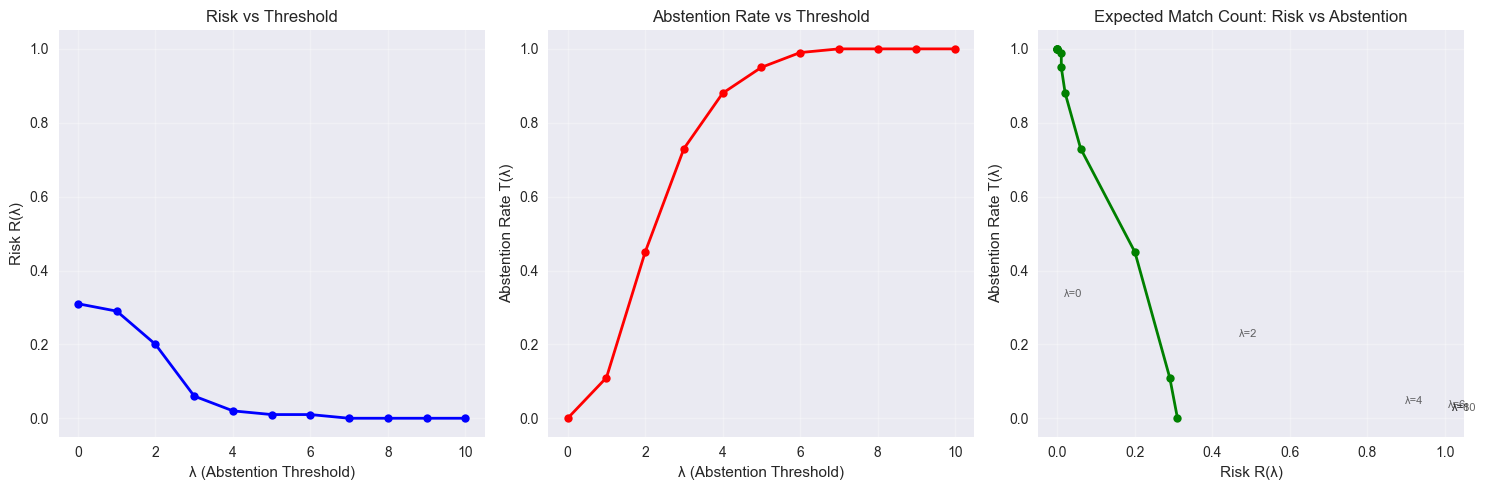


2. Match Count Score Function Results (with Beta = 8 for matching to greedy response):


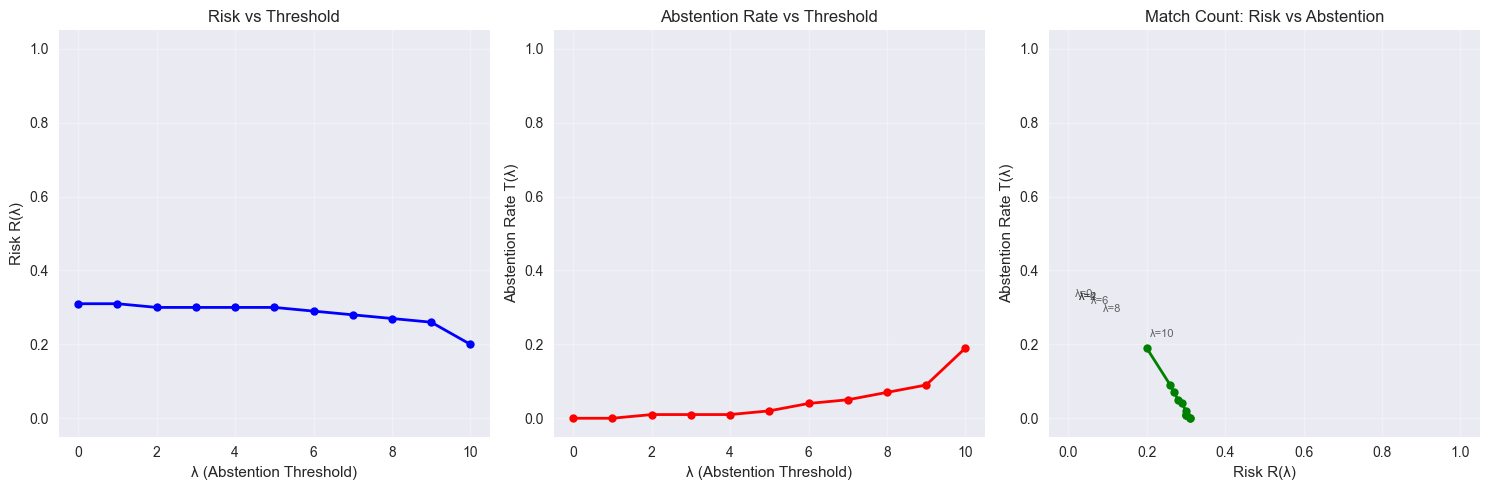


3. Comparison of Both Scoring Functions:


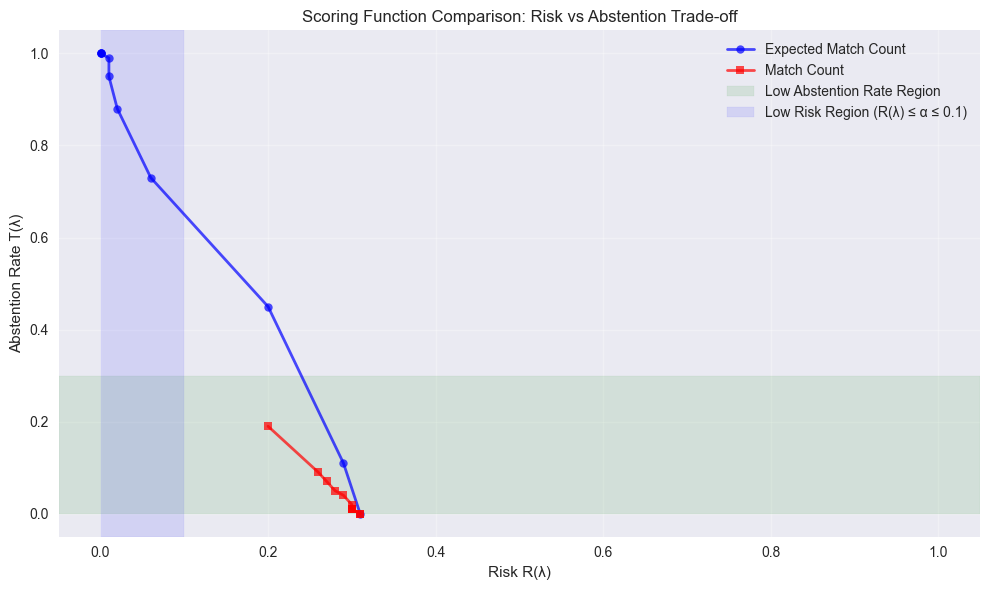


SUMMARY ANALYSIS
Calibration dataset size: 100 samples
Score range: 0 to 10 (k = number of additional responses)

Expected Match Count Performance (EMC):
  λ=0: Risk=0.310, Abstention Rate=0.000
  λ=1: Risk=0.290, Abstention Rate=0.110
  λ=2: Risk=0.200, Abstention Rate=0.450
  λ=3: Risk=0.060, Abstention Rate=0.730
  λ=4: Risk=0.020, Abstention Rate=0.880
  λ=5: Risk=0.010, Abstention Rate=0.950
  λ=6: Risk=0.010, Abstention Rate=0.990
  λ=7: Risk=0.000, Abstention Rate=1.000
  λ=8: Risk=0.000, Abstention Rate=1.000
  λ=9: Risk=0.000, Abstention Rate=1.000
  λ=10: Risk=0.000, Abstention Rate=1.000

Match Count Performance (MC), with Beta = 8 for matching to greedy response:
  λ=0: Risk=0.310, Abstention Rate=0.000
  λ=1: Risk=0.310, Abstention Rate=0.000
  λ=2: Risk=0.300, Abstention Rate=0.010
  λ=3: Risk=0.300, Abstention Rate=0.010
  λ=4: Risk=0.300, Abstention Rate=0.010
  λ=5: Risk=0.300, Abstention Rate=0.020
  λ=6: Risk=0.290, Abstention Rate=0.040
  λ=7: Risk=0.280, Abstentio

In [20]:
def plot_risk_abstention_tradeoff(
    results: dict, title: str = "Risk vs Abstention Trade-off"
):
    """
    Visualize the risk-abstention trade-off curve.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    lambdas = results["lambdas"]
    risks = results["risks"]
    abstention_rates = results["abstention_rates"]

    # Plot 1: Risk vs λ
    axes[0].plot(lambdas, risks, "b-o", linewidth=2, markersize=6)
    axes[0].set_xlabel("λ (Abstention Threshold)")
    axes[0].set_ylabel("Risk R(λ)")
    axes[0].set_title("Risk vs Threshold")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(-0.05, 1.05)

    # Plot 2: Abstention Rate vs λ
    axes[1].plot(lambdas, abstention_rates, "r-o", linewidth=2, markersize=6)
    axes[1].set_xlabel("λ (Abstention Threshold)")
    axes[1].set_ylabel("Abstention Rate T(λ)")
    axes[1].set_title("Abstention Rate vs Threshold")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(-0.05, 1.05)

    # Plot 3: Risk vs Abstention Rate
    axes[2].plot(risks, abstention_rates, "g-o", linewidth=2, markersize=6)
    axes[2].set_xlabel("Risk R(λ)")
    axes[2].set_ylabel("Abstention Rate T(λ)")
    axes[2].set_title(f"{title}")
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlim(-0.05, 1.05)
    axes[2].set_ylim(-0.05, 1.05)

    # Add annotations for key points
    for i, lambda_val in enumerate(lambdas[::2]):  # Annotate every other point
        if i * 2 < len(lambdas):
            idx = i * 2
            axes[2].annotate(
                f"λ={lambda_val}",
                (abstention_rates[idx], risks[idx]),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                alpha=0.7,
            )

    plt.tight_layout()
    plt.show()

    return fig, axes


# Plot Expected Match Count results
print("\n1. Expected Match Count Score Function Results:")
plot_risk_abstention_tradeoff(results_emc, "Expected Match Count: Risk vs Abstention")

# Plot Match Count results
print(
    "\n2. Match Count Score Function Results (with Beta = 8 for matching to greedy response):"
)
plot_risk_abstention_tradeoff(results_mc, "Match Count: Risk vs Abstention")

# Create comparison plot
print("\n3. Comparison of Both Scoring Functions:")
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot both curves on same plot
ax.plot(
    results_emc["risks"],
    results_emc["abstention_rates"],
    "b-o",
    linewidth=2,
    markersize=6,
    label="Expected Match Count",
    alpha=0.7,
)
ax.plot(
    results_mc["risks"],
    results_mc["abstention_rates"],
    "r-s",
    linewidth=2,
    markersize=6,
    label="Match Count",
    alpha=0.7,
)

ax.set_xlabel("Risk R(λ)")
ax.set_ylabel("Abstention Rate T(λ)")
ax.set_title("Scoring Function Comparison: Risk vs Abstention Trade-off")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Add ideal region annotation
ax.axhspan(0, 0.3, alpha=0.1, color="green", label="Low Abstention Rate Region")
ax.axvspan(0, 0.1, alpha=0.1, color="blue", label="Low Risk Region (R(λ) ≤ α ≤ 0.1)")

ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("SUMMARY ANALYSIS")
print("=" * 70)

print(f"Calibration dataset size: {len(calibration_data)} samples")
print(f"Score range: 0 to {K_SAMPLES} (k = number of additional responses)")

print("\nExpected Match Count Performance (EMC):")
for i, (lam, risk, abs_rate) in enumerate(
    zip(results_emc["lambdas"], results_emc["risks"], results_emc["abstention_rates"])
):
    print(f"  λ={lam}: Risk={risk:.3f}, Abstention Rate={abs_rate:.3f}")

print("\nMatch Count Performance (MC), with Beta = 8 for matching to greedy response:")
for i, (lam, risk, abs_rate) in enumerate(
    zip(results_mc["lambdas"], results_mc["risks"], results_mc["abstention_rates"])
):
    print(f"  λ={lam}: Risk={risk:.3f}, Abstention Rate={abs_rate:.3f}")

# Find optimal λ for different risk tolerances
risk_tolerances = [0.05, 0.10, 0.15, 0.20]
print("\nOptimal λ for Different Risk Tolerances α:")
print(f"{'α':>6} {'EMC λ':>8} {'EMC T(λ)':>10} {'MC λ':>8} {'MC T(λ)':>10}")
print("-" * 50)

for alpha in risk_tolerances:
    # Find optimal λ for Expected Match Count
    emc_valid = [
        (lambda_val, risk, abs_rate)
        for lambda_val, risk, abs_rate in zip(
            results_emc["lambdas"],
            results_emc["risks"],
            results_emc["abstention_rates"],
        )
        if risk <= alpha
    ]
    emc_optimal = emc_valid[0] if emc_valid else (None, None, None)

    # Find optimal λ for Match Count
    mc_valid = [
        (lambda_val, risk, abs_rate)
        for lambda_val, risk, abs_rate in zip(
            results_mc["lambdas"], results_mc["risks"], results_mc["abstention_rates"]
        )
        if risk <= alpha
    ]
    mc_optimal = mc_valid[0] if mc_valid else (None, None, None)

    # Format values properly - handle None/N/A cases
    emc_lambda_str = (
        f"{emc_optimal[0]:>8}" if emc_optimal[0] is not None else f"{'N/A':>8}"
    )
    emc_abstention_str = (
        f"{emc_optimal[2]:>10.3f}" if emc_optimal[2] is not None else f"{'N/A':>10}"
    )
    mc_lambda_str = (
        f"{mc_optimal[0]:>8}" if mc_optimal[0] is not None else f"{'N/A':>8}"
    )
    mc_abstention_str = (
        f"{mc_optimal[2]:>10.3f}" if mc_optimal[2] is not None else f"{'N/A':>10}"
    )

    print(
        f"{alpha:>6.2f} {emc_lambda_str} {emc_abstention_str} {mc_lambda_str} {mc_abstention_str}"
    )

# Evaluating on Test Set
We can also try to apply the abstention policy on the test data. Let's evaluate whether the model correctly abtains when the prediction was incorrect, using the human annotation as ground truth.

The confusion matrix should look as follows:
|                  |                 | Should abstain? |               |
|------------------|-----------------|:---------------:|:-------------:|
|                  |                 | Abstain?        | Don’t Abstain |
| Human Annotation | Model Incorrect | True Pos        | False Neg     |
|                  | Model Correct   | False Pos       | True Neg      |

In [30]:
# construct a confusion matrix for the test set
def construct_confusion_matrix(test_data, score_fn, abstention_threshold):
    """
    Construct a confusion matrix for the test set using the given score function and abstention threshold.

    Args:
        test_data: List of image data dictionaries
        score_fn: Score function to use
        abstention_threshold: Abstention threshold to use

    Returns:
        dict: Confusion matrix that includes the following keys:
            - true_positive
            - false_positive
            - true_negative
            - false_negative
            - total_model_correct
            - total_model_incorrect
            - total_model_abstained
            - total_model_not_abstained
    """
    confusion_matrix = {
        "true_positive": 0,
        "false_positive": 0,
        "true_negative": 0,
        "false_negative": 0,
        "total_model_correct": 0,
        "total_model_incorrect": 0,
        "total_model_abstained": 0,
        "total_model_not_abstained": 0,
    }
    for image_data in test_data:
        # check what true outcome was
        ground_truth = image_data["gpt4o_code"]
        was_correct = ground_truth == "yes"
        if was_correct:
            confusion_matrix["total_model_correct"] += 1
        else:
            confusion_matrix["total_model_incorrect"] += 1

        # TODO: should probably use a_lambda here
        # check if we should abstain
        should_abstain = score_fn(image_data) < abstention_threshold
        if should_abstain:
            confusion_matrix["total_model_abstained"] += 1
        else:
            confusion_matrix["total_model_not_abstained"] += 1

        # check if we abstained correctly
        if should_abstain and not was_correct:
            confusion_matrix["true_positive"] += 1
        elif should_abstain and was_correct:
            confusion_matrix["false_positive"] += 1
        elif not should_abstain and not was_correct:
            confusion_matrix["false_negative"] += 1
        elif not should_abstain and was_correct:
            confusion_matrix["true_negative"] += 1
    return confusion_matrix


def compute_roc_curve(confusion_matrix: dict) -> tuple:
    """
    Compute the ROC curve for the given confusion matrix.

    Args:
        confusion_matrix: Confusion matrix to compute the ROC curve for. Must contain the following keys:
            - true_positive
            - false_positive
            - true_negative
            - false_negative

    Returns:
        tuple: True positive rate, false positive rate
    """
    # compute the true positive rate
    true_positive_rate = confusion_matrix["true_positive"] / (
        confusion_matrix["true_positive"] + confusion_matrix["false_negative"]
    )
    # compute the false positive rate
    false_positive_rate = confusion_matrix["false_positive"] / (
        confusion_matrix["false_positive"] + confusion_matrix["true_negative"]
    )
    return true_positive_rate, false_positive_rate


def evaluate_test_set_varying_abstention_threshold(
    dataset: list, score_fn: Callable
) -> dict:
    """
    Evaluate the test set abstention accuracy across a range of λ values.

    Args:
        dataset: List of image data dictionaries
        score_fn: Score function to use

    Returns:
        dict: Contains 'lambdas', confusion matrix, and ROC curve (true positive rate, false positive rate)
    """
    k = len(dataset[0].get("additional_responses", []))
    lambda_range = list(range(0, k + 1))

    results = {"lambdas": [], "confusion_matrix": [], "roc_curve": []}

    print(f"Evaluating λ ∈ {lambda_range} on test set of {len(dataset)} examples...")
    for lambda_val in tqdm(lambda_range, desc="Evaluating λ"):
        confusion_matrix = construct_confusion_matrix(dataset, score_fn, lambda_val)
        results["lambdas"].append(lambda_val)
        results["confusion_matrix"].append(confusion_matrix)
        results["roc_curve"].append(compute_roc_curve(confusion_matrix))

    return results

In [ ]:
# load data

# including VLM prompt
# test_data = json.load(open("results/test-data-scored_300-examples_vlm-prompt_07-29-25.json"))

# not including VLM prompt
test_data = json.load(
    open("results/test-data-scored_300-examples_no-vlm-prompt_07-30-25.json")
)

In [46]:
print("Computing test set performance with Expected Match Count Score Function:")
results_emc = evaluate_test_set_varying_abstention_threshold(
    test_data, greedy_expected_match_count_score
)

print("=" * 70)

print("Test Set Performance with Match Count Score Function:")
results_mc = evaluate_test_set_varying_abstention_threshold(
    test_data, greedy_match_count_score
)

Computing test set performance with Expected Match Count Score Function:
Evaluating λ ∈ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] on test set of 300 examples...


Evaluating λ:   0%|          | 0/11 [00:00<?, ?it/s]

Test Set Performance with Match Count Score Function:
Evaluating λ ∈ [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] on test set of 300 examples...


Evaluating λ:   0%|          | 0/11 [00:00<?, ?it/s]

In [29]:
# save results as json
os.makedirs("results", exist_ok=True)
with open(
    f"results/test-data-scored_{len(test_data)}-examples_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.json",
    "w",
) as f:
    json.dump(test_data, f, indent=4)

### Plot ROC

In [48]:
def plot_roc_curves(results_emc: dict, results_mc: dict) -> None:
    """
    Plot ROC curves for Expected Match Count and Match Count scoring functions.

    Args:
        results_emc: Results from evaluate_test_set_varying_abstention_threshold using Expected Match Count scoring function
        results_mc: Results from evaluate_test_set_varying_abstention_threshold using Match Count scoring function

    Returns:
        None
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    # Plot ROC curves
    results_emc_tpr = [tpr for tpr, _ in results_emc["roc_curve"]]
    results_emc_fpr = [fpr for _, fpr in results_emc["roc_curve"]]
    results_emc_lambdas = results_emc["lambdas"]
    results_mc_tpr = [tpr for tpr, _ in results_mc["roc_curve"]]
    results_mc_fpr = [fpr for _, fpr in results_mc["roc_curve"]]
    results_mc_lambdas = results_mc["lambdas"]

    ax.plot(
        results_emc_fpr,
        results_emc_tpr,
        "b-o",
        linewidth=2,
        markersize=8,
        label="Expected Match Count",
        alpha=0.8,
    )
    ax.plot(
        results_mc_fpr,
        results_mc_tpr,
        "r-s",
        linewidth=2,
        markersize=8,
        label="Match Count",
        alpha=0.8,
    )

    # Plot diagonal reference line (random classifier)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1, label="Random Classifier")

    # Formatting
    ax.set_xlabel(
        "False Positive Rate (FPR)\nRate at which policy incorrectly abstains when model was correct",
        fontsize=12,
    )
    ax.set_ylabel(
        "True Positive Rate (TPR)\n Rate at which policy correctly abstains when model was incorrect",
        fontsize=12,
    )
    ax.set_title(
        f"ROC Curve for Test Set (N = {len(test_data)}) using Abstention Policy with Lambda from {min(results_emc_lambdas)} to {max(results_emc_lambdas)}; VLM Prompt NOT Included",
        fontsize=14,
        pad=20,
    )

    # Set ticks
    major_ticks = np.arange(0, 1.1, 0.1)
    minor_ticks = np.arange(0, 1.1, 0.05)
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_yticks(minor_ticks, minor=True)

    # Grid
    ax.grid(True, which="major", alpha=0.6)
    ax.grid(True, which="minor", alpha=0.3)

    # Set axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Add lambda annotations for Expected Match Count
    for i, (fpr, tpr, lam) in enumerate(
        zip(
            results_emc_fpr,
            results_emc_tpr,
            results_emc_lambdas,
        )
    ):
        ax.annotate(
            f"λ={lam}",
            (fpr, tpr),
            xytext=(0, 15),
            textcoords="offset points",
            fontsize=9,
            color="black",
            alpha=0.8,
        )

    # Add lambda annotations for Match Count
    for i, (fpr, tpr, lam) in enumerate(
        zip(
            results_mc_fpr,
            results_mc_tpr,
            results_mc_lambdas,
        )
    ):
        ax.annotate(
            f"λ={lam}",
            (fpr, tpr),
            xytext=(0, -15),
            textcoords="offset points",
            fontsize=9,
            color="black",
            alpha=0.8,
        )

    # Legend
    ax.legend(loc="lower right", fontsize=11)

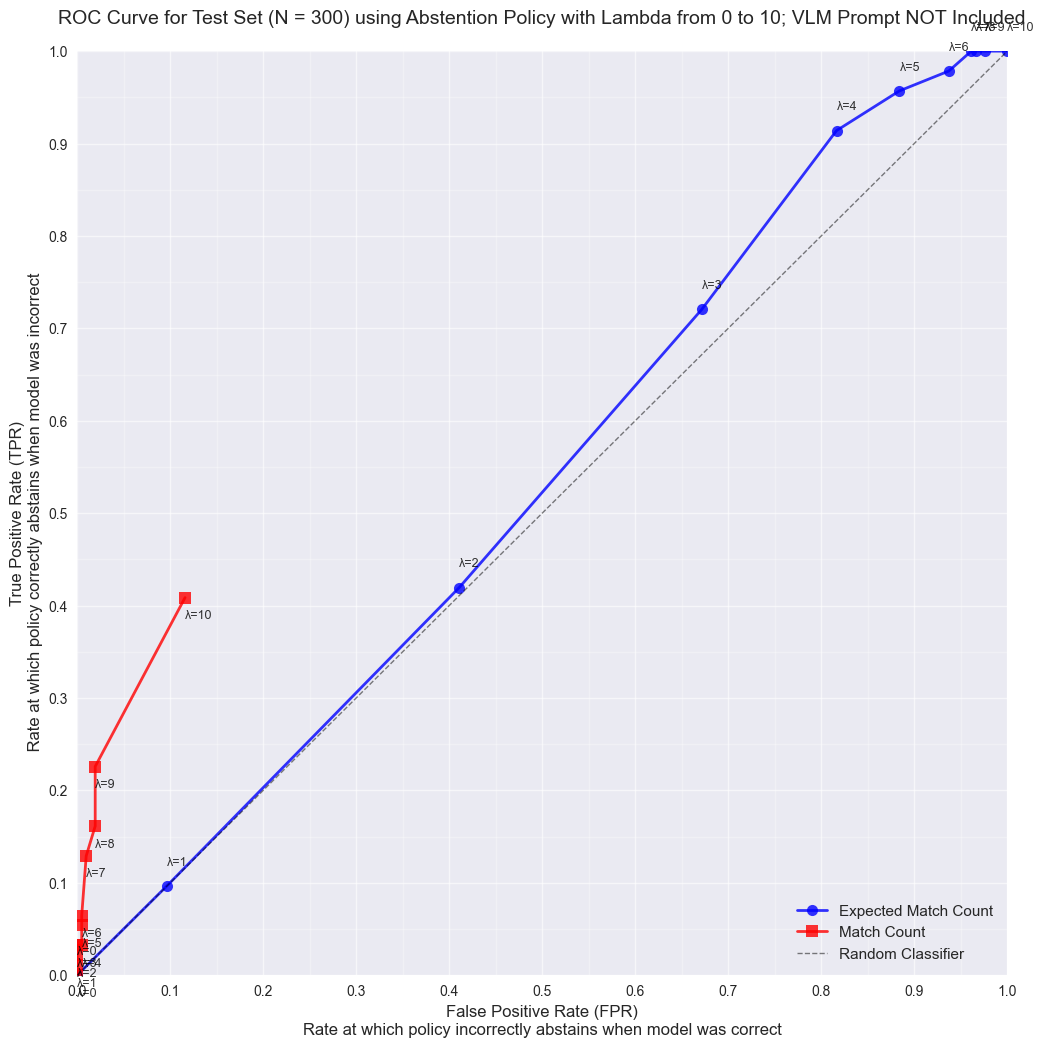

In [49]:
# Create the ROC curve plot
plot_roc_curves(results_emc, results_mc)

## Export as CSV

In [ ]:
# load data

# including VLM prompt
# test_data = json.load(
#     open("results/test-data-scored_300-examples_vlm-prompt_07-29-25.json")
# )

# not including VLM prompt
test_data = json.load(
    open("results/test-data-scored_300-examples_no-vlm-prompt_07-30-25.json")
)

In [61]:
test_data[0]

{'image_id': 1308,
 'file_name': 'VizWiz_train_00001308.jpg',
 'vizwiz_url': 'https://vizwiz.cs.colorado.edu/VizWiz_visualization_img/VizWiz_train_00001308.jpg',
 'human_captions': 'a small 330 ml bottle of praise French salad dressing\nA picture of the food is on the packaging.\nSmall blue and green French dressing bottle laying sideways.\nA person holding a bottle of French dressing by Praise in green and blue lettering on a tan placemat.\na bottle of French salad dressing brand by praise',
 'annotator': 'Anne Marie',
 'annotation': 'praise french dressing',
 'gpt4o_caption': 'A bottle of Praise French dressing with a green cap, featuring a blue label with text "French" and product details. The bottle is being held over a woven mat.',
 'gpt4o_code': 'yes',
 'greedy_response': 'A bottle of Praise French dressing with a green cap and a blue label. The label includes images of garlic and herbs, and text indicating it is a 330ml bottle with no preservatives, artificial colors, or flavors

In [ ]:
output_data = copy.deepcopy(test_data)
for index, image_data in enumerate(output_data):
    # unpack additional samples
    for sample_index, additional_sample in enumerate(
        image_data["additional_responses"]
    ):
        output_data[index][f"Sample {sample_index + 1}"] = additional_sample
    output_data[index].pop("additional_responses")

    # unpack expected match count score
    output_data[index]["Exp Match Count Score"] = image_data[
        "expected_match_count_scores"
    ]["expected_value"]
    output_data[index]["Exp Match Count Token Probs"] = image_data[
        "expected_match_count_scores"
    ]["token_probs"]
    output_data[index].pop("expected_match_count_scores")

    # unpack match count score
    output_data[index]["Match Count Score (match threshold = 8)"] = image_data[
        "match_count_scores"
    ]["total_matches"]
    for similarity_index, similarity_score in enumerate(
        image_data["match_count_scores"]["similarity_scores"]
    ):
        output_data[index][f"Similarity Score {similarity_index + 1}"] = (
            similarity_score
        )
    output_data[index].pop("match_count_scores")

# save as csv
output_df = pd.DataFrame(output_data)
# output_df.to_csv(
#     "results/test-data-scored_300-examples_vlm-prompt_07-29-25.csv", index=False
# )

output_df.to_csv(
    "results/test-data-scored_300-examples_no-vlm-prompt_07-30-25.csv", index=False
)

## Looking at Stop Words

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download("stopwords")
stopwords = set(stopwords.words("english"))


def process_caption(sentence, stopwords=None):
    """Tokenize the caption, removes punctuation, and removes stopwords if provided.
    Args:
        sentence (str): The caption to process.
        stopwords (set, optional): The set of stopwords to remove. Defaults to None.

    Returns:
        list: The list of words in the caption without punctuation and stopwords (if provided).
    """
    # get tokens
    tokens = word_tokenize(sentence)

    # strip punctuation from tokens
    words = [word.lower() for word in tokens if word.isalpha()]

    # remove stop words
    if stopwords:
        words = [word for word in words if word not in stopwords]

    return words

[nltk_data] Downloading package stopwords to /Users/kgarg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
# count the words in the caption
for index, image in enumerate(test_data):
    # get the caption
    caption = image["greedy_response"]

    words_without_punctuation = process_caption(caption)
    words_without_punctuation_and_stopwords = process_caption(caption, stopwords)

    # get the unique words in the caption
    test_data[index]["word_count_all"] = len(words_without_punctuation)
    test_data[index]["word_count_no_stopwords"] = len(
        words_without_punctuation_and_stopwords
    )
    test_data[index]["unique_word_count_no_stopwords"] = len(
        set(words_without_punctuation_and_stopwords)
    )

In [ ]:
# get average of word count all, no stopwords, and unique words no stopwords
word_count_all = [image["word_count_all"] for image in test_data]
word_count_no_stopwords = [image["word_count_no_stopwords"] for image in test_data]
unique_word_count_no_stopwords = [
    image["unique_word_count_no_stopwords"] for image in test_data
]

# average
print(f"Average word count all: {np.mean(word_count_all)}")
print(f"Average word count no stopwords: {np.mean(word_count_no_stopwords)}")
print(
    f"Average unique word count no stopwords: {np.mean(unique_word_count_no_stopwords)}"
)

# median
print(f"Median word count all: {np.median(word_count_all)}")
print(f"Median word count no stopwords: {np.median(word_count_no_stopwords)}")
print(
    f"Median unique word count no stopwords: {np.median(unique_word_count_no_stopwords)}"
)

Average word count all: 27.833333333333332
Average word count no stopwords: 16.44
Average unique word count no stopwords: 15.193333333333333
Median word count all: 28.0
Median word count no stopwords: 16.0
Median unique word count no stopwords: 15.0
